# Lecture : Graph Convolutional Networks

## Lab 03 : GAT -- Solution

### Xavier Bresson, Nian Liu, Guoji Fu

Velickovic, Cucurull, Casanova, Romero, Lio, Bengio, Graph Attention Networks, 2017      
https://arxiv.org/pdf/1710.10903

In [1]:
# For Google Colaboratory
import sys, os

if "google.colab" in sys.modules:
    # mount google drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    path_to_file = '/content/gdrive/My Drive/CS5284_2026_codes/06_Graph_Convnets'
    print(path_to_file)
    # change current path to the folder containing "path_to_file"
    os.chdir(path_to_file)
    !pwd
    !pip install torch-geometric==2.8.0.post1 # Install PyG

In [2]:
# Libraries
import math
import time
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import add_self_loops, degree, from_networkx, softmax, to_networkx

_ = torch.manual_seed(0)

# Visualize the artificial graph dataset used in this notebook

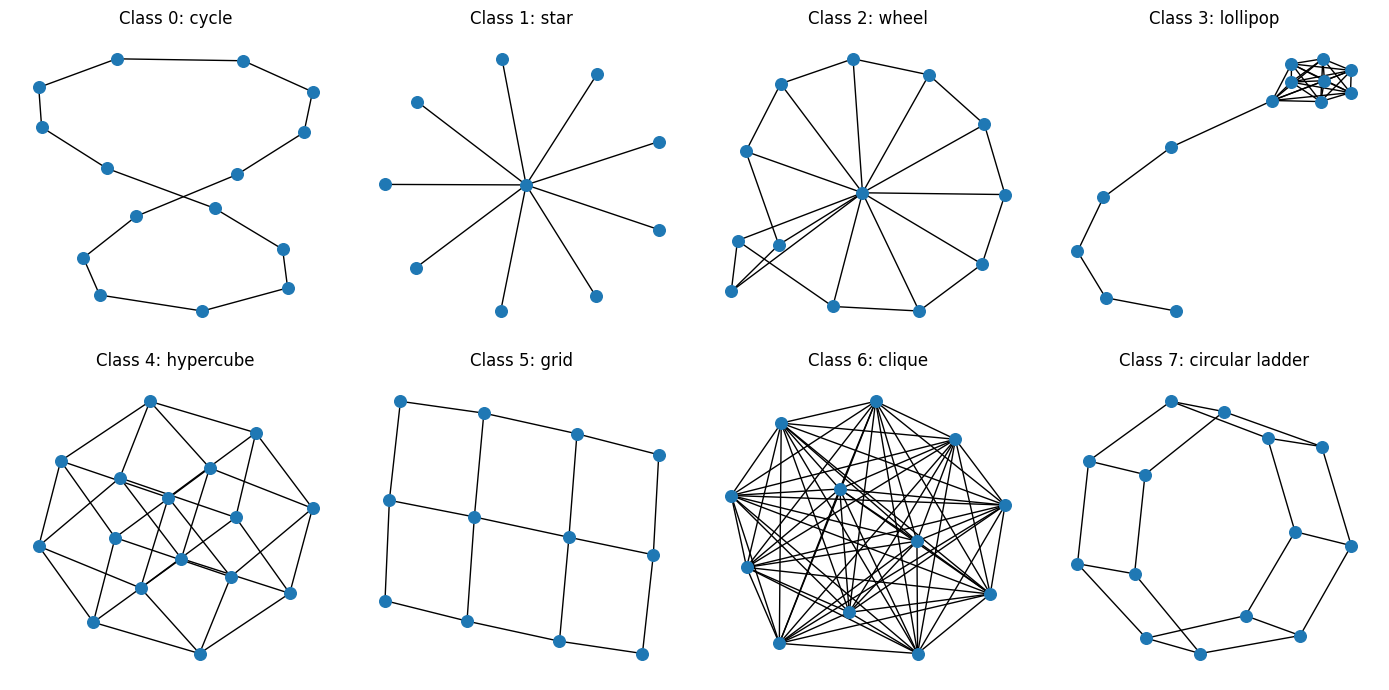

In [3]:
CLASS_NAMES = [
    "cycle", "star", "wheel", "lollipop",
    "hypercube", "grid", "clique", "circular ladder",
]


# Convert a simple undirected NetworkX graph to a PyG Data object.
# PyG stores an undirected edge in both directions in edge_index. We also add
# one self-loop per node, matching the preprocessing in DGL MiniGCDataset.
def networkx_to_pyg(graph, label):
    graph = nx.convert_node_labels_to_integers(graph)
    data = from_networkx(graph)
    data.edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
    data.y = torch.tensor([label], dtype=torch.long)
    return data


# Reproduce the eight graph families of DGL MiniGCDataset as PyG Data objects.
def generate_minigc_pyg(num_graphs, min_num_v, max_num_v, seed=0):
    rng = np.random.RandomState(seed)
    dataset = []
    graphs_per_class = num_graphs // 8

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.cycle_graph(num_v), 0))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.star_graph(num_v - 1), 1))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.wheel_graph(num_v), 2))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        path_len = int(rng.randint(2, num_v // 2))
        dataset.append(networkx_to_pyg(nx.lollipop_graph(num_v - path_len, path_len), 3))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dimension = int(math.log(num_v, 2))
        dataset.append(networkx_to_pyg(nx.hypercube_graph(dimension), 4))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        num_rows = int(rng.randint(2, num_v // 2))
        num_cols = num_v // num_rows
        dataset.append(networkx_to_pyg(nx.grid_graph([num_rows, num_cols]), 5))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.complete_graph(num_v), 6))

    while len(dataset) < num_graphs:
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.circular_ladder_graph(num_v // 2), 7))

    return dataset


dataset = generate_minigc_pyg(8, 10, 20, seed=0)

# visualise the 8 classes of graphs
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for c, ax in enumerate(axes.ravel()):
    graph = to_networkx(dataset[c], to_undirected=True, remove_self_loops=True)
    nx.draw(graph, ax=ax, node_size=70, width=1.0)
    ax.set_title(f"Class {c}: {CLASS_NAMES[c]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Generate train, val and test datasets

## Add node feature

In [4]:
# Add node features to graphs.
def add_node_features(dataset):
    for graph in dataset:
        # node feature = node in-degree (including the self-loop)
        dst = graph.edge_index[1]
        graph.x = degree(dst, num_nodes=graph.num_nodes).view(-1, 1).float()
    return dataset


# Use different seeds so the splits do not replay the same random sequence.
# This toy generator has a small support, so exact topologies can still overlap.
trainset = add_node_features(generate_minigc_pyg(350, 10, 20, seed=0))
testset = add_node_features(generate_minigc_pyg(100, 10, 20, seed=1))
valset = add_node_features(generate_minigc_pyg(100, 10, 20, seed=2))
print(trainset[0])

Data(edge_index=[2, 45], num_nodes=15, y=[1], x=[15, 1])


# Use the PyG DataLoader to prepare a batch of graphs and test it

In [5]:
# PyG concatenates the graphs, offsets edge indices, and creates a `batch`
# vector that maps every node to its graph in the mini-batch.
batch_size = 10
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
batch_graphs = next(iter(train_loader))
batch_labels = batch_graphs.y
print(batch_graphs)
print(batch_labels)
batch_x = batch_graphs.x
print('batch_x:', batch_x.size())
print('batch vector:', batch_graphs.batch.size())

DataBatch(edge_index=[2, 681], num_nodes=135, y=[10], x=[135, 1], batch=[135], ptr=[11])
tensor([2, 2, 4, 7, 2, 7, 7, 3, 5, 3])
batch_x: torch.Size([135, 1])
batch vector: torch.Size([135])


## Question 1: Design the class of GAT networks with PyG

Update equations:  
\begin{eqnarray}
h_{i}^{\ell+1} &=  \text{Concat}_{k=1}^{K} \Big( \text{ELU} \Big( \sum_{j \in \mathcal{N}_i} e_{ij}^{k,\ell}  \ W_1^{k,\ell} \ h_{j}^{\ell} \Big) \Big)\\
e_{ij}^{k,\ell} &=\textrm{Softmax}_{\mathcal{N}_i}(\hat e_{ij}^{k,\ell})= \frac{\exp(\hat e_{ij}^{k,\ell})}{\sum_{j' \in \mathcal{N}_i} \exp(\hat e_{ij'}^{k,\ell}) } \\
\hat e_{ij}^{k,\ell} &= \text{LeakyReLU} \Big( W_2^{k,\ell} \ \text{Concat} \big( W_1^{k,\ell}h_{i}^{\ell} , \ W_1^{k,\ell}h_{j}^{\ell} \big) \ \Big)
\end{eqnarray}

Every graph contains self-loops, so $i\in\mathcal{N}_i$. In PyG, `edge_index[0]` is the source node $j$ and `edge_index[1]` is the destination node $i$.

Instructions:

Step 1: Define an attention head layer from scratch with PyG `MessagePassing`
- Apply the learnable linear map $W_1$ before message passing.
- In `message()`, calculate the unnormalized attention $\hat e_{ij}$ from the destination representation `Wh_i` and source representation `Wh_j`.
- Normalize the scores over all incoming neighbors of each destination node. PyG supplies the destination grouping through `index`; use `torch_geometric.utils.softmax`.
- Return $e_{ij}Wh_j$. The `MessagePassing` base class then sums these messages for every destination node.

Step 2: Define a multiple attention head layer
- Apply Step 1 independently in every head and concatenate the head outputs.
- Each head is expected to capture a distinct similarity property between nodes.

Do not call PyG's `GATConv`: the purpose of this exercise is to implement the GAT update itself.

In [6]:
# MLP layer for classification
class MLP_layer(nn.Module):

    def __init__(self, input_dim, output_dim, L=2): # L = nb of hidden layers
        super().__init__()
        list_FC_layers = [nn.Linear(input_dim, input_dim, bias=True) for _ in range(L)]
        list_FC_layers.append(nn.Linear(input_dim, output_dim, bias=True))
        self.FC_layers = nn.ModuleList(list_FC_layers)
        self.L = L

    def forward(self, x):
        y = x
        for l in range(self.L):
            y = self.FC_layers[l](y)
            y = torch.relu(y)
        y = self.FC_layers[self.L](y)
        return y


class GAT_one_head(MessagePassing):
    def __init__(self, input_dim, output_dim):
        # PyG propagates messages from edge_index[0] (source/j) to
        # edge_index[1] (destination/i), then sums them at each destination.
        super().__init__(aggr='add', flow='source_to_target')
        self.W = nn.Linear(input_dim, output_dim, bias=True)
        self.a = nn.Linear(2 * output_dim, 1, bias=False)

    def message(self, Wh_i, Wh_j, index, ptr, size_i):
        # `Wh_i` and `Wh_j` are destination/source features for every edge.
        ########################################
        # YOUR CODE STARTS HERE
        # Step 1: calculate and normalize attention, then weight source messages.
        ########################################
        WhiWhj = torch.cat((Wh_i, Wh_j), dim=-1)
        # Following the GAT paper, use LeakyReLU with negative_slope=0.2.
        eij = F.leaky_relu(self.a(WhiWhj), negative_slope=0.2)
        alpha = softmax(eij, index=index, ptr=ptr, num_nodes=size_i)
        message = alpha * Wh_j
        ########################################
        # YOUR CODE ENDS HERE
        ########################################
        return message

    def forward(self, x, edge_index):
        Wh = self.W(x)
        h = self.propagate(edge_index, Wh=Wh)
        return F.elu(h)


class GAT_layer(nn.Module):

    def __init__(self, input_dim, num_heads, output_dim):
        super().__init__()
        self.GAT_one_heads = nn.ModuleList([
            GAT_one_head(input_dim, output_dim) for _ in range(num_heads)
        ])

    def forward(self, x, edge_index):
        h_in = x # shared input for all attention heads
        list_h = []
        ########################################
        # YOUR CODE STARTS HERE
        # Step 2: apply every head and concatenate their outputs.
        ########################################
        for GAT_one_head in self.GAT_one_heads:
            list_h.append(GAT_one_head(h_in, edge_index))
        h = torch.cat(list_h, dim=-1)
        ########################################
        # YOUR CODE ENDS HERE
        ########################################
        return h


class GAT_net(nn.Module):

    def __init__(self, net_parameters):
        super().__init__()
        input_dim = net_parameters['input_dim']
        num_heads = net_parameters['num_heads']
        hidden_dim = net_parameters['hidden_dim']
        output_dim = net_parameters['output_dim']
        L = net_parameters['L']
        assert hidden_dim % num_heads == 0
        self.embedding_h = nn.Linear(input_dim, hidden_dim)
        self.GAT_layers = nn.ModuleList([
            GAT_layer(hidden_dim, num_heads, hidden_dim // num_heads)
            for _ in range(L)
        ])
        self.MLP_layer = MLP_layer(hidden_dim, output_dim)

    def forward(self, data):
        h = self.embedding_h(data.x)

        for GATlayer in self.GAT_layers:
            h = GATlayer(h, data.edge_index)

        # Mean graph pooling uses the PyG batch vector to pool each graph.
        y = global_mean_pool(h, data.batch)
        y = self.MLP_layer(y)
        return y

    def loss(self, y_scores, y_labels):
        return nn.CrossEntropyLoss()(y_scores, y_labels)

    def accuracy(self, scores, targets):
        predictions = scores.detach().argmax(dim=1)
        return (predictions == targets).float().sum().item()

    def update(self, lr):
        return torch.optim.Adam(self.parameters(), lr=lr)


# Instantiate one network (testing)
net_parameters = {}
net_parameters['input_dim'] = 1
net_parameters['num_heads'] = 4
net_parameters['hidden_dim'] = net_parameters['num_heads'] * 32
net_parameters['output_dim'] = 8 # nb of classes
net_parameters['L'] = 4
net = GAT_net(net_parameters)
print(net)


def display_num_param(net):
    nb_param = sum(param.numel() for param in net.parameters())
    print('Number of parameters: {} ({:.2f} million)'.format(nb_param, nb_param / 1e6))
    return nb_param / 1e6


display_num_param(net)
batch_scores = net(batch_graphs)
print('batch_scores:', batch_scores.size())

GAT_net(
  (embedding_h): Linear(in_features=1, out_features=128, bias=True)
  (GAT_layers): ModuleList(
    (0-3): 4 x GAT_layer(
      (GAT_one_heads): ModuleList(
        (0-3): 4 x GAT_one_head()
      )
    )
  )
  (MLP_layer): MLP_layer(
    (FC_layers): ModuleList(
      (0-1): 2 x Linear(in_features=128, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=8, bias=True)
    )
  )
)
Number of parameters: 101384 (0.10 million)
batch_scores: torch.Size([10, 8])


# Train the network

In [7]:
def run_one_epoch(net, data_loader, train=True):
    if train:
        net.train()
    else:
        net.eval()

    epoch_loss = 0.0
    epoch_acc = 0.0
    nb_data = 0

    for batch_graphs in data_loader:
        batch_labels = batch_graphs.y
        batch_scores = net(batch_graphs)
        loss = net.loss(batch_scores, batch_labels)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        batch_count = batch_labels.size(0)
        epoch_loss += loss.detach().item() * batch_count
        epoch_acc += net.accuracy(batch_scores, batch_labels)
        nb_data += batch_count

    epoch_loss /= nb_data
    epoch_acc /= nb_data
    return epoch_loss, epoch_acc


# dataset loaders
train_loader = DataLoader(trainset, batch_size=50, shuffle=True)
test_loader = DataLoader(testset, batch_size=50, shuffle=False)
val_loader = DataLoader(valset, batch_size=50, shuffle=False)

# Instantiate one network
_ = torch.manual_seed(0)
net_parameters = {}
net_parameters['input_dim'] = 1
net_parameters['num_heads'] = 4
net_parameters['hidden_dim'] = net_parameters['num_heads'] * 32
net_parameters['output_dim'] = 8 # nb of classes
net_parameters['L'] = 4
net = GAT_net(net_parameters)
display_num_param(net)

# optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=0.0001)

# training loop
for epoch in range(50):
    start = time.time()
    epoch_train_loss, epoch_train_acc = run_one_epoch(net, train_loader, True)
    with torch.no_grad():
        epoch_test_loss, epoch_test_acc = run_one_epoch(net, test_loader, False)
        epoch_val_loss, epoch_val_acc = run_one_epoch(net, val_loader, False)
    if not epoch % 2:
        print('Epoch {}, time {:.4f}, train_loss: {:.4f}, test_loss: {:.4f}, val_loss: {:.4f}'.format(
            epoch, time.time() - start, epoch_train_loss, epoch_test_loss, epoch_val_loss))
        print('                      train_acc: {:.4f}, test_acc: {:.4f}, val_acc: {:.4f}'.format(
            epoch_train_acc, epoch_test_acc, epoch_val_acc))

Number of parameters: 101384 (0.10 million)
Epoch 0, time 0.2339, train_loss: 2.0703, test_loss: 2.0629, val_loss: 2.0628
                      train_acc: 0.1829, test_acc: 0.1300, val_acc: 0.1300
Epoch 2, time 0.2046, train_loss: 2.0398, test_loss: 2.0318, val_loss: 2.0316
                      train_acc: 0.1229, test_acc: 0.1200, val_acc: 0.1200
Epoch 4, time 0.1915, train_loss: 1.9961, test_loss: 1.9800, val_loss: 1.9797
                      train_acc: 0.1229, test_acc: 0.1200, val_acc: 0.1200
Epoch 6, time 0.1938, train_loss: 1.9172, test_loss: 1.8906, val_loss: 1.8907
                      train_acc: 0.1457, test_acc: 0.1600, val_acc: 0.1900
Epoch 8, time 0.1902, train_loss: 1.7953, test_loss: 1.7559, val_loss: 1.7566
                      train_acc: 0.2743, test_acc: 0.2800, val_acc: 0.3100
Epoch 10, time 0.1894, train_loss: 1.6220, test_loss: 1.5680, val_loss: 1.5706
                      train_acc: 0.5457, test_acc: 0.5400, val_acc: 0.5700
Epoch 12, time 0.1933, train_loss: 1.